In [1]:
import hydranet

import pandas as pd


weights = hydranet.get_model_weights(
    training="finetuning",
    model="student",
    task="lc",
    n_shots=5000,
    download_dir="./weights",
)
print(weights)


Found latest checkpoint from 20260108
  Downloading: UNet_Myriad2_Downstream_unfrozen_best.pt


  Saved to: weights/finetuning/hydranet/lc_nshot5000_frozen/lc/20260108_UNet_Myriad2_Downstream_unfrozen_5000/UNet_Myriad2_Downstream_unfrozen_best.pt
['weights/finetuning/hydranet/lc_nshot5000_frozen/lc/20260108_UNet_Myriad2_Downstream_unfrozen_5000/UNet_Myriad2_Downstream_unfrozen_best.pt']


In [2]:
import hydranet
import pandas as pd
from pathlib import Path

# Download / resolve available weights
weights = hydranet.get_model_weights(
    training="finetuning",
    model="student",
    task="lc",
    n_shots=5000,
    download_dir="./weights",
)

print("Resolved weights:")
for w in weights:
    print(w)

# Locate the catalogue CSV inside hydranet installation
catalogue_path = Path(hydranet.__file__).parent / "model_weights.csv"

print("\nCatalogue path:")
print(catalogue_path)

# Load catalogue
df = pd.read_csv(catalogue_path)

# Show all available checkpoints
display(df)

# Optional: only LC checkpoints
display(df[df["task"].str.contains("lc", case=False, na=False)])

Found latest checkpoint from 20260108
  Downloading: UNet_Myriad2_Downstream_unfrozen_best.pt
  Saved to: weights/finetuning/hydranet/lc_nshot5000_frozen/lc/20260108_UNet_Myriad2_Downstream_unfrozen_5000/UNet_Myriad2_Downstream_unfrozen_best.pt
Resolved weights:
weights/finetuning/hydranet/lc_nshot5000_frozen/lc/20260108_UNet_Myriad2_Downstream_unfrozen_5000/UNet_Myriad2_Downstream_unfrozen_best.pt

Catalogue path:
/shared/home/ivanderspoel/hydranet-phisat2/src/hydranet/model_weights.csv


,file_path,training,model,task,n_shots,datetime,filename
0,finetuning/hydranet/anomaly_detection_nshot100...,finetuning,student,anomaly_detection,1000.0,20251215,UNet_Myriad2_Downstream_unfrozen_best.pt
1,finetuning/hydranet/anomaly_detection_nshot100...,finetuning,student,anomaly_detection,1000.0,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt
2,finetuning/hydranet/anomaly_detection_nshot100...,finetuning,student,anomaly_detection,100.0,20251215,UNet_Myriad2_Downstream_unfrozen_best.pt
3,finetuning/hydranet/anomaly_detection_nshot100...,finetuning,student,anomaly_detection,100.0,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt
4,finetuning/hydranet/anomaly_detection_nshot500...,finetuning,student,anomaly_detection,5000.0,20251215,UNet_Myriad2_Downstream_unfrozen_best.pt
...,...,...,...,...,...,...,...
395,linear_probing/phisatnet/worldfloods_nshot100_...,linear_probing,teacher,worldfloods,100.0,20251213,PhiSatNetDownstream_frozen_best.pt
396,linear_probing/phisatnet/worldfloods_nshot5000...,linear_probing,teacher,worldfloods,5000.0,20251213,PhiSatNetDownstream_frozen_best.pt
397,linear_probing/phisatnet/worldfloods_nshot500_...,linear_probing,teacher,worldfloods,500.0,20251213,PhiSatNetDownstream_frozen_best.pt
398,linear_probing/phisatnet/worldfloods_nshot50_f...,linear_probing,teacher,worldfloods,50.0,20251212,PhiSatNetDownstream_frozen_best.pt


,file_path,training,model,task,n_shots,datetime,filename
70,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20251218,UNet_Myriad2_Downstream_unfrozen_best.pt
71,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20251219,UNet_Myriad2_Downstream_unfrozen_best.pt
72,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20251228,UNet_Myriad2_Downstream_unfrozen_best.pt
73,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20251230,UNet_Myriad2_Downstream_unfrozen_best.pt
74,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20251231,UNet_Myriad2_Downstream_unfrozen_best.pt
75,finetuning/hydranet/lc_nshot1000_frozen/lc/202...,finetuning,student,lc,1000.0,20260108,UNet_Myriad2_Downstream_unfrozen_best.pt
76,finetuning/hydranet/lc_nshot100_frozen/lc/2025...,finetuning,student,lc,100.0,20251218,UNet_Myriad2_Downstream_unfrozen_best.pt
77,finetuning/hydranet/lc_nshot100_frozen/lc/2025...,finetuning,student,lc,100.0,20251219,UNet_Myriad2_Downstream_unfrozen_best.pt
78,finetuning/hydranet/lc_nshot100_frozen/lc/2025...,finetuning,student,lc,100.0,20251228,UNet_Myriad2_Downstream_unfrozen_best.pt
79,finetuning/hydranet/lc_nshot100_frozen/lc/2025...,finetuning,student,lc,100.0,20251230,UNet_Myriad2_Downstream_unfrozen_best.pt


In [3]:
teacher = hydranet.load_teacher(
    task="segmentation",      # architecture mode
    pretrained_path=weights[0],
    input_dim=8,
    output_dim=11,
    depths=[2, 2, 6, 2],
    dims=[64, 128, 256, 512],
    img_size=256,
)

Loading segmentation model


/shared/home/ivanderspoel/hydranet-phisat2/src/hydranet/models/teacher.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_path, map_loc

product_id: 1346
sim shape: (8, 256, 256)
s2b shape: (7, 256, 256)
real shape: (8, 256, 256)


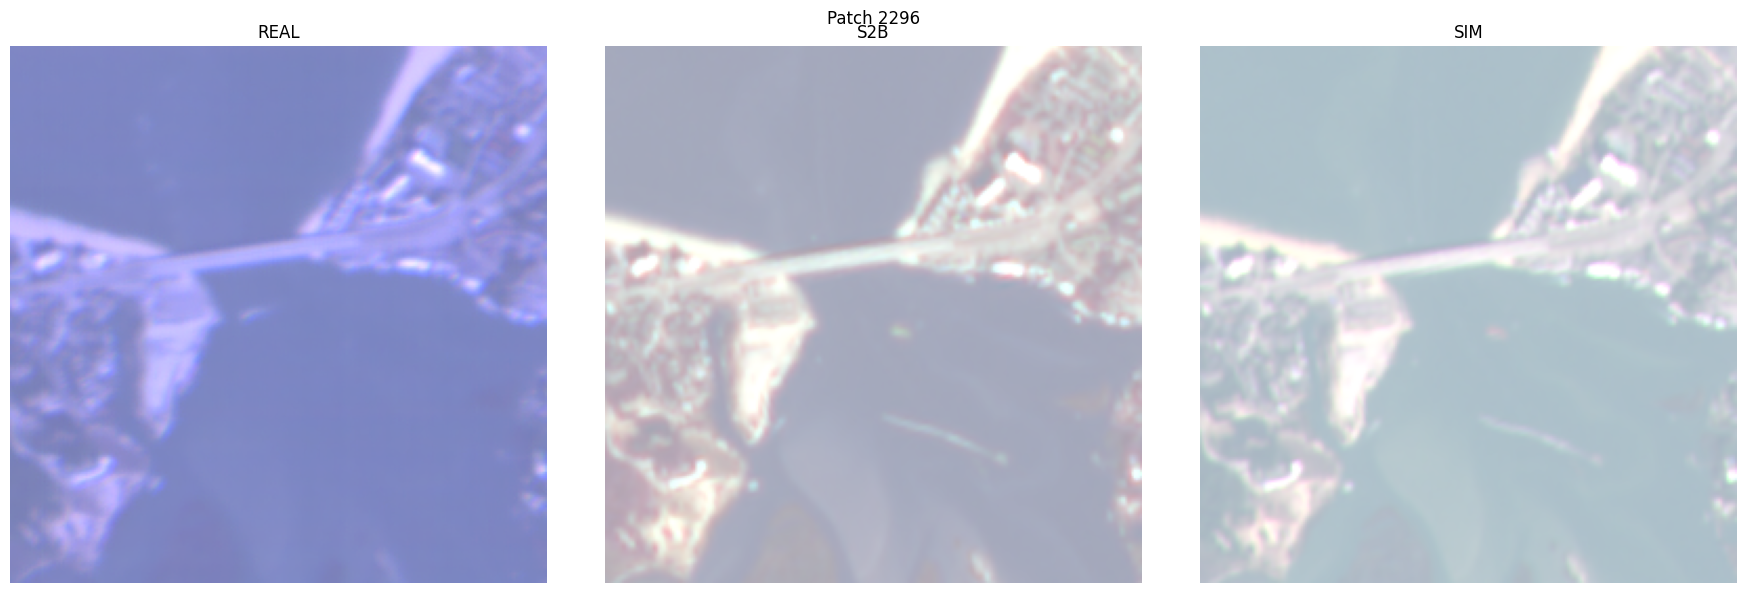

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

H5_PATH = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"

PATCH_IDX = 2296

with h5py.File(H5_PATH, "r") as f:

    sim = f["sim/images"][PATCH_IDX]        # (8,256,256)
    s2b = f["s2b/images"][PATCH_IDX]        # (7,256,256)
    real = f["real/images"][PATCH_IDX]      # (8,256,256) usually

    scl = f["s2b/masks"][PATCH_IDX]

    product_id = f["metadata/product_id"][PATCH_IDX]

    print("product_id:", product_id)
    print("sim shape:", sim.shape)
    print("s2b shape:", s2b.shape)
    print("real shape:", real.shape)


def make_rgb(img, r=3, g=2, b=1):
    rgb = np.stack([
        img[r],   # red
        img[g],   # green
        img[b],   # blue
    ], axis=-1)

    rgb = np.sqrt(np.maximum(rgb, 0))
    rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

    return rgb


# Create RGB previews
rgb_real = make_rgb(real)
rgb_s2b = make_rgb(s2b)
rgb_sim = make_rgb(sim)

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_real)
axes[0].set_title("REAL")
axes[0].axis("off")

axes[1].imshow(rgb_s2b)
axes[1].set_title("S2B")
axes[1].axis("off")

axes[2].imshow(rgb_sim)
axes[2].set_title("SIM")
axes[2].axis("off")

plt.suptitle(f"Patch {PATCH_IDX}")
plt.tight_layout()
plt.show()

In [ ]:
x = sim
SIM_MEAN = np.array([
    49.7866, 49.0253, 48.4297, 49.2364,
    51.1648, 55.4065, 57.3572, 56.7808
], dtype=np.float32)

SIM_STD = np.array([
    7.2800, 6.5203, 6.9570, 9.0981,
    8.3858, 7.9555, 8.3155, 8.3664
], dtype=np.float32)

x = np.clip(x, 0, 100)
x = np.sqrt(np.maximum(sim.astype(np.float32), 0))

#x = sim
x = (x - SIM_MEAN[:, None, None]) / SIM_STD[:, None, None]

x = x[[1, 2, 3, 0, 7, 4, 5, 6]]
#x = x[[7, 0, 1, 2, 3, 4, 5 ,6]]

In [29]:
import torch
import hydranet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"

# ESA WorldCover classes
esa_codes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]

class_names = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse Vegetation",
    70: "Snow and Ice",
    80: "Permanent Water Bodies",
    90: "Herbaceous Wetland",
    95: "Mangroves",
    100: "Moss and Lichen",
}

index_to_esa = {i: code for i, code in enumerate(esa_codes)}

# Categorical plotting setup
num_classes = len(esa_codes)
cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, num_classes)))
norm = BoundaryNorm(np.arange(-0.5, num_classes + 0.5, 1), cmap.N)

# Catalogue
catalogue_path = Path(hydranet.__file__).parent / "model_weights.csv"
df = pd.read_csv(catalogue_path)
# Load both finetuning and selected linear probing checkpoints
lc_df = (
    df[
        (df["model"] == "student")
        & (df["task"] == "lc")
        & (df["n_shots"] == 5000)
        & (
            (df["training"] == "finetuning")
            |
            (
                (df["training"] == "linear_probing")
                & (df["datetime"].astype(int).isin([20251228, 20251230, 20260108]))
            )
        )
    ]
    .sort_values(["training", "datetime"])
    .reset_index(drop=True)
)

print(lc_df[["datetime", "training", "file_path", "filename"]])

models = []

for _, row in lc_df.iterrows():
    training = row["training"]
    dt = int(row["datetime"])

    print(f"Loading checkpoint training={training}, datetime={dt}")

    weight_path = hf_hub_download(
        repo_id="sirbastiano94/hydranet",
        filename=row["file_path"],
        repo_type="dataset",
        local_dir="./weights",
    )

    model = hydranet.load_student(
        task="lc",
        n_shots=5000,
        training=training,          # <-- important: finetuning or linear_probing
        weights_dir="./weights",
        auto_load_weights=False,
        strict=False,
    ).to(device)

    ckpt = torch.load(weight_path, map_location="cpu")
    state = ckpt.get("state_dict", ckpt)
    model_state = model.state_dict()

    cleaned = {}
    for k, v in state.items():
        kk = k.replace("model.", "").replace("net.", "")
        if kk in model_state and model_state[kk].shape == v.shape:
            cleaned[kk] = v

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    model.eval()

    print(f"Loaded {len(cleaned)} tensors")
    print(f"Missing: {len(missing)}, unexpected: {len(unexpected)}")

    models.append((training, dt, model))

print(f"Loaded {len(models)} LC models.")

   datetime        training  \
0  20251218      finetuning   
1  20251219      finetuning   
2  20251228      finetuning   
3  20251230      finetuning   
4  20251231      finetuning   
5  20260108      finetuning   
6  20251228  linear_probing   
7  20251230  linear_probing   
8  20260108  linear_probing   

                                           file_path  \
0  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
1  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
2  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
3  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
4  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
5  finetuning/hydranet/lc_nshot5000_frozen/lc/202...   
6  linear_probing/hydranet/lc_nshot5000_frozen/lc...   
7  linear_probing/hydranet/lc_nshot5000_frozen/lc...   
8  linear_probing/hydranet/lc_nshot5000_frozen/lc...   

                                   filename  
0  UNet_Myriad2_Downstream_unfrozen_best.pt  
1  UNet_Myriad2_Downstream_unfrozen_

/tmp/ipykernel_4005653/1322799595.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weight_path, map_location="cpu")


Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=finetuning, datetime=20251219
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=finetuning, datetime=20251228
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=finetuning, datetime=20251230
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=finetuning, datetime=20251231
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=finetuning, datetime=20260108
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=linear_probing, datetime=20251228
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=linear_probing, datetime=20251230
Loaded 97 tensors
Missing: 9, unexpected: 0
Loading checkpoint training=linear_probing, datetime=20260108
Loaded 97 tensors
Missing: 9, unexpected: 0
Loaded 9 LC models.


In [33]:
tensor = torch.from_numpy(x).float().unsqueeze(0).to(device)

predictions = []

for training, dt, model in models:
    print(f"Running inference for {training} checkpoint {dt}")

    with torch.no_grad():
        logits = model(tensor)
        pred_idx = logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)

    pred_esa = np.vectorize(index_to_esa.get)(pred_idx).astype(np.uint8)

    predictions.append((training, dt, pred_idx, pred_esa))

print("Done.")

Running inference for finetuning checkpoint 20251218
Running inference for finetuning checkpoint 20251219
Running inference for finetuning checkpoint 20251228
Running inference for finetuning checkpoint 20251230
Running inference for finetuning checkpoint 20251231
Running inference for finetuning checkpoint 20260108
Running inference for linear_probing checkpoint 20251228
Running inference for linear_probing checkpoint 20251230
Running inference for linear_probing checkpoint 20260108
Done.


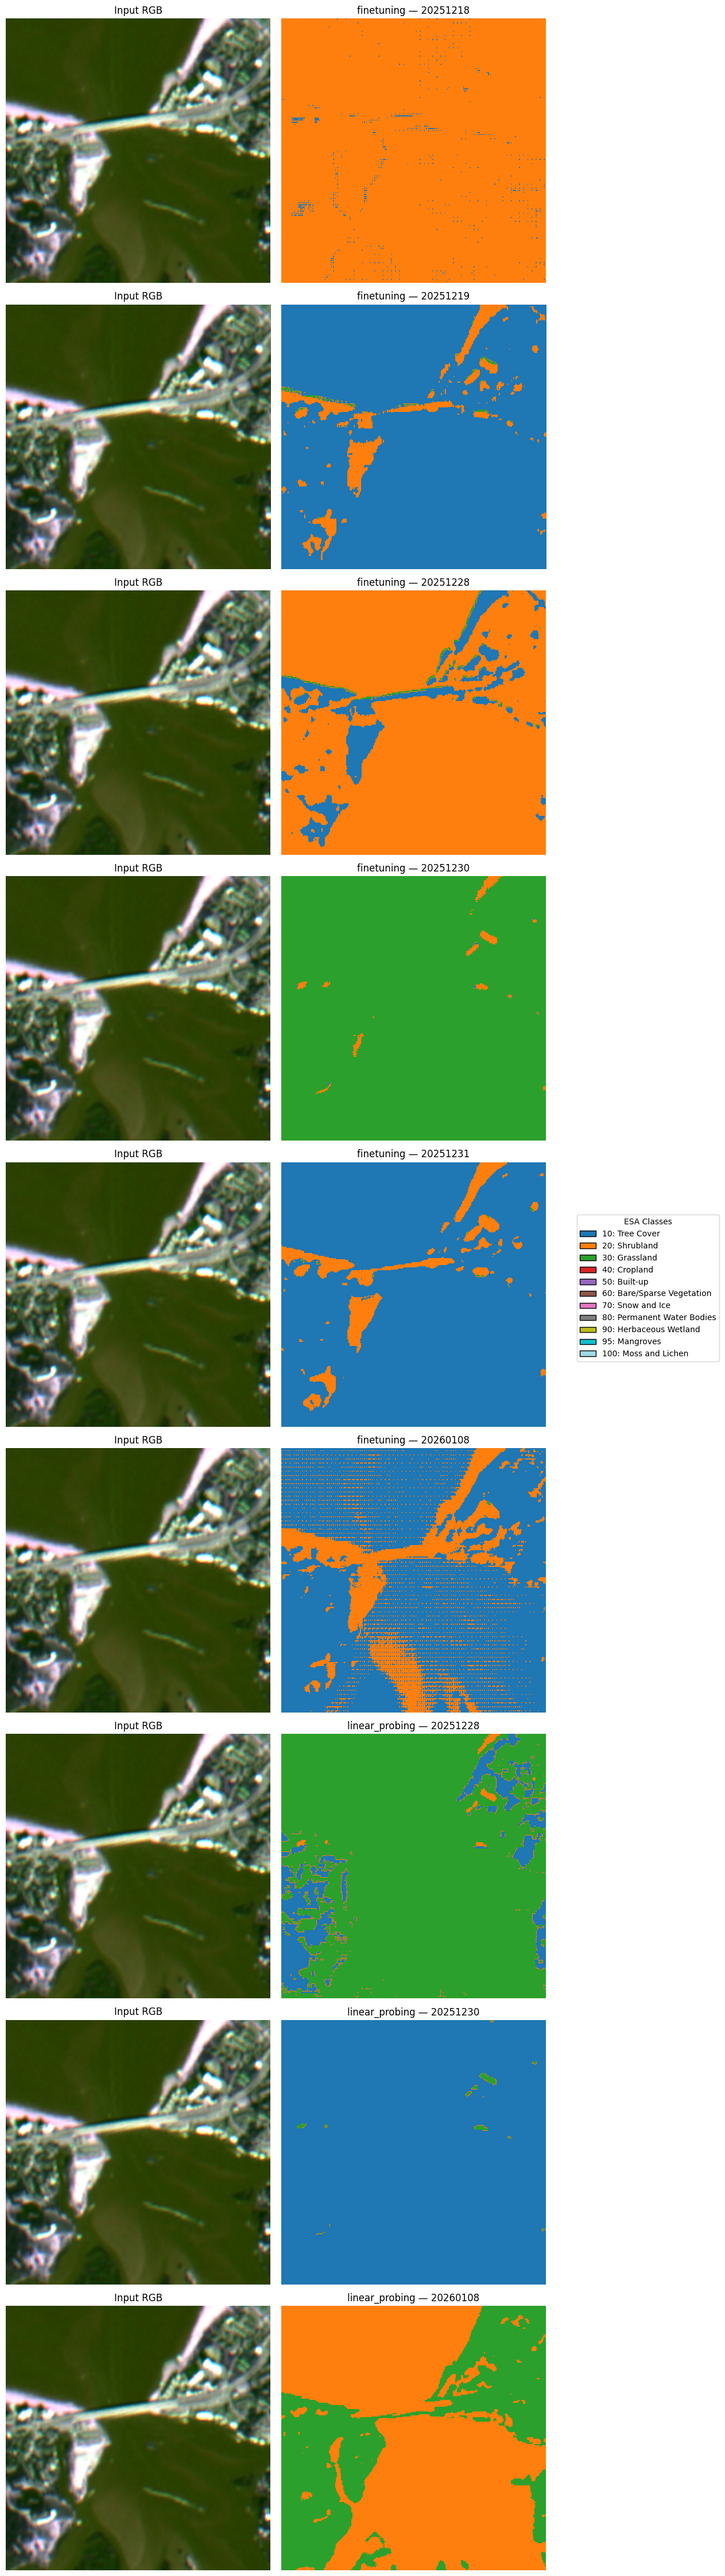

In [34]:
# Optional RGB visualization from x
# Assumes x shape = (8, H, W)
# Change band indices if needed for your dataset
rgb = np.stack([
    x[3],  # R
    x[2],  # G
    x[1],  # B
], axis=-1)

# Normalize RGB for display
rgb_min = np.percentile(rgb, 2)
rgb_max = np.percentile(rgb, 98)
rgb_vis = np.clip((rgb - rgb_min) / (rgb_max - rgb_min), 0, 1)

# Plot input image + prediction side-by-side
n = len(predictions)
fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (training, dt, pred_idx, pred_esa) in enumerate(predictions):
    axes[row, 0].imshow(rgb_vis)
    axes[row, 0].set_title("Input RGB")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_idx, cmap=cmap, norm=norm)
    axes[row, 1].set_title(f"{training} — {dt}")
    axes[row, 1].axis("off")

# Legend
legend_patches = [
    Patch(
        facecolor=cmap(i),
        edgecolor="black",
        label=f"{esa_codes[i]}: {class_names[esa_codes[i]]}"
    )
    for i in range(num_classes)
]

fig.legend(
    handles=legend_patches,
    loc="center right",
    bbox_to_anchor=(1.28, 0.5),
    title="ESA Classes"
)

plt.tight_layout()
plt.show()